Epoch 0, Loss: 11.16338333333334
Epoch 100, Loss: 0.23890619844622016
Epoch 200, Loss: 0.046741641277938416
Epoch 300, Loss: 0.043361391656440706
Epoch 400, Loss: 0.043301931335165855
Final m, b: 0.17306214911917545 3.330101475599946


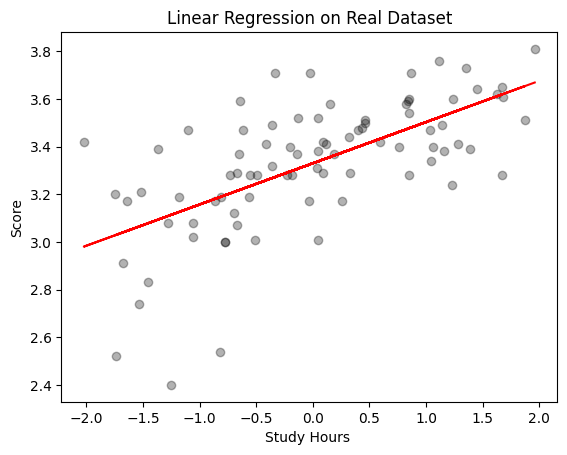

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("/content/Simple linear regression.csv")


data.columns = ['Hours', 'Score']

def loss_function(m, b, points):
    totalError = 0
    for i in range(len(points)):
        x = points.iloc[i].Hours
        y = points.iloc[i].Score
        totalError += (y - (m * x + b))**2
    return totalError / len(points)

def gradient_descent(m_now, b_now, points, L):
    m_gradient = 0
    b_gradient = 0
    n = len(points)

    for i in range(len(points)):
        x = points.iloc[i].Hours
        y = points.iloc[i].Score

        m_gradient += -(2/n) * x * (y - (m_now * x + b_now))
        b_gradient += -(2/n) * (y - (m_now * x + b_now))

    m_now = m_now - L * m_gradient
    b_now = b_now - L * b_gradient

    return m_now, b_now

data['Hours'] = (data['Hours'] - data['Hours'].mean()) / data['Hours'].std()

m = 0
b = 0
L = 0.01
epochs = 500

for i in range(epochs):
    if i % 100 == 0:
        print(f"Epoch {i}, Loss: {loss_function(m, b, data)}")
    m, b = gradient_descent(m, b, data, L)

print("Final m, b:", m, b)

# Plot
plt.scatter(data.Hours, data.Score, color="black", alpha=0.3)

x_vals = data.Hours
y_vals = m * x_vals + b

plt.plot(x_vals, y_vals, color="red")
plt.xlabel("Study Hours ")
plt.ylabel("Score")
plt.title("Linear Regression on Real Dataset")
plt.show()